In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def bloch_sphere():
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Plot sphere
    u, v = np.mgrid[0:2*np.pi:50j, 0:np.pi:25j]
    x = np.cos(u)*np.sin(v)
    y = np.sin(u)*np.sin(v)
    z = np.cos(v)
    ax.plot_wireframe(x, y, z, color='gray', alpha=0.2)

    # Plot x, y, and z axes
    ax.plot([-1, 1], [0, 0], [0, 0], 'k-', linewidth=1)
    ax.plot([0, 0], [-1, 1], [0, 0], 'k-', linewidth=1)
    ax.plot([0, 0], [0, 0], [-1, 1], 'k-', linewidth=1)

    # Set aspect ratio
    ax.set_box_aspect([1,1,1])

    # Set labels and limits
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])

    return fig, ax

In [2]:
def Sx():
    Sx = np.array([[ 0, 1],
               [ 1, 0]])
    return Sx
def Sy():
    Sy = np.array([[ 0,-1j],
               [1j, 0]])
    return Sy
def Sz():
    Sz = np.array([[ 1, 0],
               [ 0,-1]])
    return Sz

In [3]:
from scipy.linalg import fractional_matrix_power
def state_fidelity(rho_1, rho_2): #fidelity
        if np.shape(rho_1) != np.shape(rho_2):
            print("Dimensions of two states do not match.")
            return 0
        else:
            sqrt_rho_1 = fractional_matrix_power(rho_1, 1 / 2)
            fidelity = np.trace(fractional_matrix_power(sqrt_rho_1 @ rho_2 @ sqrt_rho_1, 1 / 2)) ** 2
            return np.real(fidelity)


In [4]:
# from qutip.qip.operations import sx, sy, sz
from qutip.metrics import fidelity

def plot_fidelity_on_bloch(rho1, rho2):
    # Calculate fidelity between rho1 and rho2
    F = state_fidelity(rho1, rho2)
    theta = 2 * np.arccos(np.sqrt(F))

    # Initialize Bloch sphere
    fig, ax = bloch_sphere()

    # Plot density matrices on Bloch sphere
    bloch_vectors = [np.array([np.real(np.trace(np.dot(rho, Sx()))),
                               np.real(np.trace(np.dot(rho, Sy()))),
                               np.real(np.trace(np.dot(rho, Sz())))])
                     for rho in [rho1, rho2]]
    colors = ['red', 'blue']
    for vec, color in zip(bloch_vectors, colors):
        ax.plot([0, vec[0]], [0, vec[1]], [0, vec[2]], color=color, linewidth=2)

    # Plot fidelity arc
    u, v = np.mgrid[0:2*np.pi:100j, 0:theta:50j]
    x = np.sin(v) * np.cos(u)
    y = np.sin(v) * np.sin(u)
    z = np.cos(v)
    ax.plot(x, y, z, color='green', linewidth=2)

    # Show plot
    plt.show()

In [5]:
import numpy as np
from matplotlib import pyplot as plt

# Define density matrices
rho1 = np.array([[0.5, 0.3 + 0.2j],
                 [0.3 - 0.2j, 0.5]])
rho2 = np.array([[0.7, 0.0],
                 [0.0, 0.3]])

# Plot fidelity on bloch sphere
plot_fidelity_on_bloch(rho1, rho2)

ValueError: input operand has more dimensions than allowed by the axis remapping

AttributeError: 'Line3D' object has no attribute '_verts3d'

<Figure size 640x480 with 1 Axes>

In [6]:
from qutip.metrics import fidelity
# from qutip.qip.operations import sx, sy, sz
from qutip import Bloch

def bloch_sphere():
    # Create Bloch sphere visualization
    fig = plt.figure(figsize=(5, 5))
    ax = Axes3D(fig, azim=-40, elev=30)
    sphere = Bloch(axes=ax)
    sphere.vector_color = ['r', 'b']
    sphere.zlabel = ['', '']
    sphere.point_size = [30, 30]
    sphere.view = [-40, 30]
    sphere.font_size = 14
    sphere.make_sphere()

    return fig, ax

def plot_fidelity_on_bloch(rho1, rho2):
    # Calculate fidelity between rho1 and rho2
    F = fidelity(rho1, rho2)
    theta = 2 * np.arccos(np.sqrt(F))

    # Initialize Bloch sphere
    fig, ax = bloch_sphere()

    # Plot density matrices on Bloch sphere
    bloch_vectors = [np.array([np.real(np.trace(np.dot(rho.full(), Sx()))),
                               np.real(np.trace(np.dot(rho.full(), Sy()))),
                               np.real(np.trace(np.dot(rho.full(), Sz())))])
                     for rho in [rho1, rho2]]
    colors = ['red', 'blue']
    for vec, color in zip(bloch_vectors, colors):
        line = ax.plot([0, vec[0]], [0, vec[1]], [0, vec[2]], color=color, linewidth=2)[0]
        x, y, z = line.get_data()
        line.set_data_3d([x[0], x[-1]], [y[0], y[-1]], [z[0], z[-1]])

    # Plot fidelity arc
    u, v = np.mgrid[0:2*np.pi:100j, 0:theta:50j]
    x = np.sin(v) * np.cos(u)
    y = np.sin(v) * np.sin(u)
    z = np.cos(v)
    ax.plot(x, y, z, color='green', linewidth=2)

    # Show plot
    plt.show()

In [7]:
import numpy as np
from matplotlib import pyplot as plt

# Define density matrices
rho1 = np.array([[0.5, 0.3 + 0.2j],
                 [0.3 - 0.2j, 0.5]])
rho2 = np.array([[0.7, 0.0],
                 [0.0, 0.3]])

# Plot fidelity on bloch sphere|
plot_fidelity_on_bloch(rho1, rho2)

AttributeError: 'numpy.ndarray' object has no attribute 'isket'

In [8]:
from qutip.metrics import fidelity
from qutip.operators import sigmax, sigmay, sigmaz
from qutip import Bloch

def bloch_sphere():
    # Create Bloch sphere visualization
    fig = plt.figure(figsize=(5, 5))
    ax = Axes3D(fig, azim=-40, elev=30)
    sphere = Bloch(axes=ax)
    sphere.vector_color = ['r', 'b']
    sphere.zlabel = ['', '']
    sphere.point_size = [30, 30]
    sphere.view = [-40, 30]
    sphere.font_size = 14
    sphere.make_sphere()

    return fig, ax

def plot_fidelity_on_bloch(rho1, rho2):
    # Calculate fidelity between rho1 and rho2
    F = state_fidelity(rho1, rho2)
    theta = 2 * np.arccos(np.sqrt(F))

    # Initialize Bloch sphere
    fig, ax = bloch_sphere()

    # Plot density matrices on Bloch sphere
    bloch_vectors = [np.array([np.real(np.trace(np.dot(rho.full(), sigmax))),
                               np.real(np.trace(np.dot(rho.full(), sigmay))),
                               np.real(np.trace(np.dot(rho.full(), sigmaz)))])
                     for rho in [rho1, rho2]]
    colors = ['red', 'blue']
    for vec, color in zip(bloch_vectors, colors):
        line = ax.plot([0, vec[0]], [0, vec[1]], [0, vec[2]], color=color, linewidth=2)[0]
        x, y, z = line.get_data()
        line.set_data_3d([x[0], x[-1]], [y[0], y[-1]], [z[0], z[-1]])

    # Plot fidelity arc
    u, v = np.mgrid[0:2*np.pi:100j, 0:theta:50j]
    x = np.sin(v) * np.cos(u)
    y = np.sin(v) * np.sin(u)
    z = np.cos(v)
    ax.plot(x, y, z, color='green', linewidth=2)

    # Show plot
    plt.show()

c:\Users\Administrator\anaconda3\lib\site-packages\ipykernel_launcher.py:8: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  


AttributeError: 'numpy.ndarray' object has no attribute 'full'

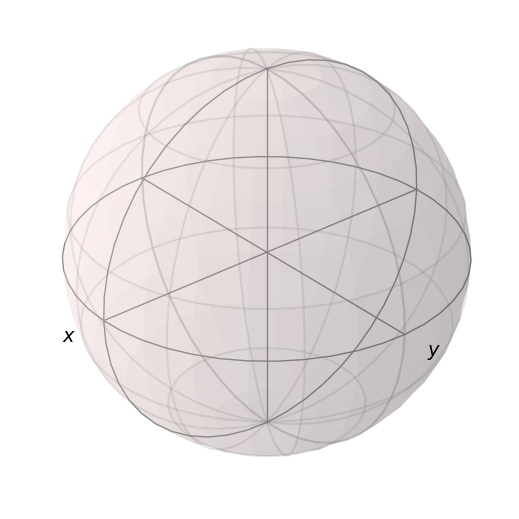

In [9]:
import numpy as np
from matplotlib import pyplot as plt

# Define density matrices
rho1 = np.array([[0.5, 0.3 + 0.2j],
                 [0.3 - 0.2j, 0.5]])
rho2 = np.array([[0.7, 0.0],
                 [0.0, 0.3]])

# Plot fidelity on bloch sphere
plot_fidelity_on_bloch(rho1, rho2)

In [29]:
from qutip.metrics import fidelity
from qutip.operators import sigmax, sigmay, sigmaz
from qutip import Bloch, Qobj

def bloch_sphere():
    # Create Bloch sphere visualization
    fig = plt.figure(figsize=(5, 5))
    ax = Axes3D(fig, azim=-40, elev=30)
    sphere = Bloch(axes=ax)
    sphere.vector_color = ['r', 'b']
    sphere.zlabel = ['', '']
    sphere.point_size = [30, 30]
    sphere.view = [-40, 30]
    sphere.font_size = 14
    sphere.make_sphere()

    return fig, ax

def plot_fidelity_on_bloch(rho1, rho2):
    # Calculate fidelity between rho1 and rho2
    F = state_fidelity(rho1, rho2)
    theta = 2 * np.arccos(np.sqrt(F))

    # Initialize Bloch sphere
    fig, ax = bloch_sphere()

    # Plot density matrices on Bloch sphere
    bloch_vectors = [np.array([np.real(np.trace(Qobj(rho).full() @ sigmax)),
                               np.real(np.trace(Qobj(rho).full() @ sigmay)),
                               np.real(np.trace(Qobj(rho).full() @ sigmaz))])
                     for rho in [rho1, rho2]]
    colors = ['red', 'blue']
    for vec, color in zip(bloch_vectors, colors):
        line = ax.plot([0, vec[0]], [0, vec[1]], [0, vec[2]], color=color, linewidth=2)[0]
        x, y, z = line.get_data()
        line.set_data_3d([x[0], x[-1]], [y[0], y[-1]], [z[0], z[-1]])

    # Plot fidelity arc
    u, v = np.mgrid[0:2*np.pi:100j, 0:theta:50j]
    x = np.sin(v) * np.cos(u)
    y = np.sin(v) * np.sin(u)
    z = np.cos(v)
    ax.plot(x, y, z, color='green', linewidth=2)

    # Show plot
    plt.show()

c:\Users\Administrator\anaconda3\lib\site-packages\ipykernel_launcher.py:8: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  


ValueError: matmul: Input operand 1 does not have enough dimensions (has 0, gufunc core with signature (n?,k),(k,m?)->(n?,m?) requires 1)

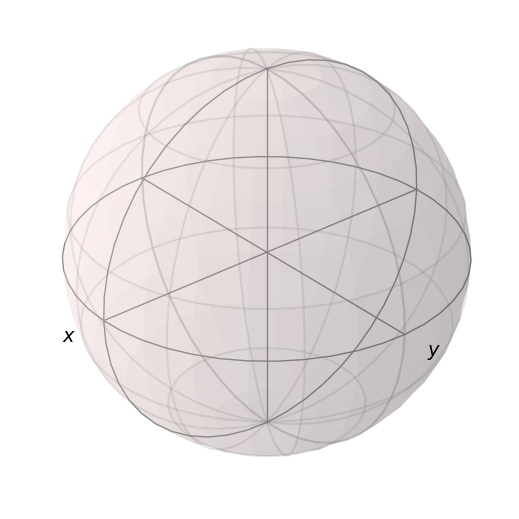

In [30]:
import numpy as np
from matplotlib import pyplot as plt

# Define density matrices
rho1 = np.array([[0.5, 0.3 + 0.2j],
                 [0.3 - 0.2j, 0.5]])
rho2 = np.array([[0.7, 0.0],
                 [0.0, 0.3]])

# Plot fidelity on bloch sphere
plot_fidelity_on_bloch(rho1, rho2)